<a href="https://colab.research.google.com/github/Hanaa879/Student-Performance-Analytics-System/blob/main/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#@title Student Performance Analytics System & Dashboard { run: "auto" }
%matplotlib inline

# Python libraries for data analysis, model training and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [5]:
from google.colab import drive
drive.mount('/content/drive')

# This code is to find the way to the drive for the specific file
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/StudentsPerformance.csv')

# Display basic information about the dataset
print("First 5 Rows:")
print(data.head())
print("\nDataset Shape:", data.shape)
print("\nColumn Names:")
print(data.columns)
print("\nDataset Information:")
data.info()
print("\nMissing Values:")
print(data.isnull().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First 5 Rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Dataset Shape: 

In [6]:
# Step 1: Create Average Score
data['Average_Score'] = data[['math score', 'reading score', 'writing score']].mean(axis=1)

# Step 2: Create Target Columns
data['Performance'] = np.where(data['Average_Score'] >= 60, 1, 0)

# Step 3: Targets
y_reg = data['Average_Score']
y = data['Performance']
y_clf = data['Performance']

# Step 4: Features
X_raw = data.drop(['math score', 'reading score', 'writing score', 'Average_Score', 'Performance'], axis=1)
X = pd.get_dummies(X_raw, drop_first=True)

# Step 5: Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 6: Train-Test Split
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X_scaled, y_clf, test_size=0.2, random_state=42)

print("--- Prepared Features Preview ---")
print(X.head())
print("-" * 44)
print("Preprocessing complete!")
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

--- Prepared Features Preview ---
   gender_male  race/ethnicity_group B  race/ethnicity_group C  \
0        False                    True                   False   
1        False                   False                    True   
2        False                    True                   False   
3         True                   False                   False   
4         True                   False                    True   

   race/ethnicity_group D  race/ethnicity_group E  \
0                   False                   False   
1                   False                   False   
2                   False                   False   
3                   False                   False   
4                   False                   False   

   parental level of education_bachelor's degree  \
0                                           True   
1                                          False   
2                                          False   
3                                         

In [7]:
# Linear Regression → Marks Prediction

lr = LinearRegression()
lr.fit(X_train, y_train_reg)
y_pred_reg = lr.predict(X_test)

mse = mean_squared_error(y_test_reg, y_pred_reg)
print("Linear Regression trained!")
print(f"  MSE  : {mse:.2f}")
print(f"  RMSE : {mse**0.5:.2f}")
print(f"  R²   : {lr.score(X_test, y_test_reg):.2f}")

Linear Regression trained!
  MSE  : 179.60
  RMSE : 13.40
  R²   : 0.16


In [8]:
# Logistic Regression → Pass/Fail Prediction

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train_clf)
y_pred_clf = log_reg.predict(X_test)

acc = accuracy_score(y_test_clf, y_pred_clf)
print("Logistic Regression trained!")
print(f"  Accuracy : {acc:.2%}")
print(classification_report(y_test_clf, y_pred_clf,
      target_names=['Fail', 'Pass'], zero_division=0))

Logistic Regression trained!
  Accuracy : 68.00%
              precision    recall  f1-score   support

        Fail       0.47      0.24      0.32        62
        Pass       0.72      0.88      0.79       138

    accuracy                           0.68       200
   macro avg       0.59      0.56      0.55       200
weighted avg       0.64      0.68      0.64       200



In [9]:
# Decision Tree → Academic Performance Analysis

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train_dt, y_train_dt)
y_pred_dt = model.predict(X_test_dt)

importances = model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Decision Tree trained!")
print(f"Training samples: {X_train_dt.shape[0]}")
print(f"Testing samples: {X_test_dt.shape[0]}")
print("Accuracy Score:", accuracy_score(y_test_dt, y_pred_dt))
print(classification_report(y_test_dt, y_pred_dt, target_names=['Fail', 'Pass']))

Decision Tree trained!
Training samples: 800
Testing samples: 200
Accuracy Score: 0.67
              precision    recall  f1-score   support

        Fail       0.46      0.35      0.40        62
        Pass       0.74      0.81      0.77       138

    accuracy                           0.67       200
   macro avg       0.60      0.58      0.59       200
weighted avg       0.65      0.67      0.66       200



In [10]:
# KNN → Similar Student Retrieval

categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
numerical_cols = ['math score', 'reading score', 'writing score']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])
X_processed = preprocessor.fit_transform(data)

knn = NearestNeighbors(n_neighbors=6, metric='euclidean')
knn.fit(X_processed)
print("KNN trained!")

KNN trained!


In [11]:
# Random Forest → Dropout Prediction Risk
from sklearn.ensemble import RandomForestClassifier

# 1. Split the dataset (using unscaled features for better tree interpretability)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 2. Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

# 3. Generate predictions for evaluation
y_pred_rf = rf_model.predict(X_test_rf)

print("Random Forest model trained successfully!")
print(f"Training samples: {X_train_rf.shape[0]} | Testing samples: {X_test_rf.shape[0]}")


Random Forest model trained successfully!
Training samples: 800 | Testing samples: 200


In [12]:
# K-Means → Student Grouping & Segmentation

kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
data['Cluster_Group'] = kmeans_model.fit_predict(X_scaled)

cluster_profile = data.groupby('Cluster_Group')[['math score', 'reading score', 'writing score', 'Average_Score']].mean()

print("K-Means trained!")
print("\nCluster Performance Profiles:")
display(cluster_profile.round(2))
print("\nDistribution of Students across Groups:")
print(data['Cluster_Group'].value_counts().sort_index().to_frame('Total Students'))

K-Means trained!

Cluster Performance Profiles:


,math score,reading score,writing score,Average_Score
Cluster_Group,,,,
0,66.53,68.68,66.92,67.38
1,64.46,69.10,67.83,67.13
2,67.36,70.03,70.15,69.18



Distribution of Students across Groups:
               Total Students
Cluster_Group                
0                         419
1                         319
2                         262


In [13]:
# PCA → Feature Reduction & Visualization

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_full = PCA()
pca_full.fit(X_scaled)

print("PCA trained!")
print(f"  PC1 Variance : {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2 Variance : {pca.explained_variance_ratio_[1]:.2%}")
print(f"  Total        : {sum(pca.explained_variance_ratio_):.2%}")

PCA trained!
  PC1 Variance : 12.07%
  PC2 Variance : 11.41%
  Total        : 23.48%


       Linear Regression → Marks Prediction

📊 METRICS
  MSE  : 179.60
  RMSE : 13.40
  R²   : 0.16


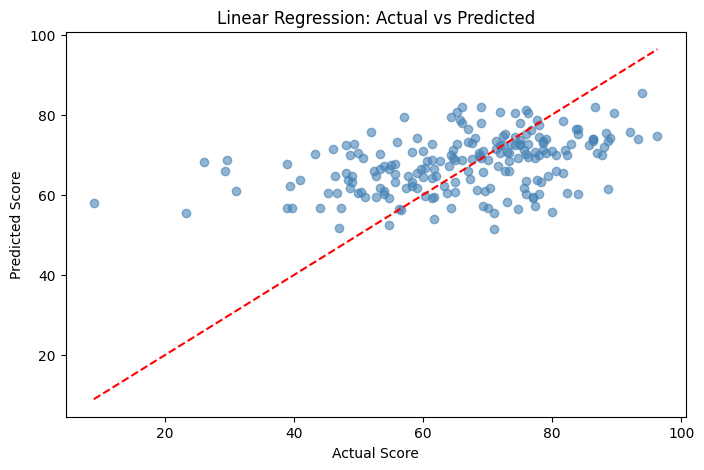

In [14]:
#@markdown Select a model from the dropdown menu to update the dashboard view.
Select_Model = "Linear Regression" #@param ["Linear Regression", "Logistic Regression", "Decision Tree", "KNN", "Random Forest", "K-Means", "PCA"]

if Select_Model == "Linear Regression":

    print("=" * 60)
    print("       Linear Regression → Marks Prediction")
    print("=" * 60)
    print(f"\n📊 METRICS")
    print(f"  MSE  : {mean_squared_error(y_test_reg, y_pred_reg):.2f}")
    print(f"  RMSE : {mean_squared_error(y_test_reg, y_pred_reg)**0.5:.2f}")
    print(f"  R²   : {lr.score(X_test, y_test_reg):.2f}")

    plt.figure(figsize=(8, 5))
    plt.scatter(y_test_reg, y_pred_reg, alpha=0.6, color='steelblue')
    plt.plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()], 'r--')
    plt.xlabel("Actual Score")
    plt.ylabel("Predicted Score")
    plt.title("Linear Regression: Actual vs Predicted")
    plt.show()


elif Select_Model == "Logistic Regression":

    print("=" * 60)
    print("       Logistic Regression → Pass/Fail Prediction")
    print("=" * 60)
    print(f"\n📊 METRICS")
    print(f"  Accuracy : {accuracy_score(y_test_clf, y_pred_clf):.2%}")
    print(f"\nClassification Report:")
    print(classification_report(y_test_clf, y_pred_clf,
          target_names=['Fail', 'Pass'], zero_division=0))

    cm = confusion_matrix(y_test_clf, y_pred_clf)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fail', 'Pass'],
                yticklabels=['Fail', 'Pass'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Logistic Regression - Confusion Matrix")
    plt.show()


elif Select_Model == "Decision Tree":

    print("=" * 60)
    print("       Decision Tree → Academic Performance Analysis")
    print("=" * 60)

    # Split data for Decision Tree (uses unscaled, one-hot encoded X and binary y)
    X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Decision Tree model
    model = DecisionTreeClassifier(max_depth=3, random_state=42)
    model.fit(X_train_dt, y_train_dt)

    # Predict and evaluate
    y_pred_dt = model.predict(X_test_dt)

    print(f"\n📊 METRICS")
    print(f"  Accuracy : {accuracy_score(y_test_dt, y_pred_dt):.2%}")
    print(classification_report(y_test_dt, y_pred_dt,
          target_names=['Fail', 'Pass']))

    plt.figure(figsize=(20, 10))
    plot_tree(model, feature_names=X.columns,
              class_names=['Fail', 'Pass'],
              filled=True, rounded=True, fontsize=12)
    plt.show()

    # Calculate feature importances
    importances = model.feature_importances_
    feature_imp_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    print("\nKey factors influencing academic performance:")
    print(feature_imp_df)


elif Select_Model == "KNN":

    print("=" * 60)
    print("       KNN → Similar Student Retrieval")
    print("=" * 60)

    def find_similar_students_dashboard(student_id, dataset, processed_data, model):
        target_student = processed_data[student_id].reshape(1, -1)
        distances, indices = model.kneighbors(target_student)
        target_info = dataset.iloc[student_id]
        similar_indices = indices[0][1:]
        similar_distances = distances[0][1:]
        results = dataset.iloc[similar_indices].copy()
        results.insert(0, 'Similarity Distance', similar_distances)

        panel_html = f"""
        <div style="background-color: #1e1e24; padding: 15px; border-radius: 8px; border-left: 5px solid #4a90e2; color: white; margin-bottom: 20px;">
            <h3 style="margin-top: 0; color: #4a90e2;">🎯 Target Profile (Student ID: {student_id})</h3>
            <p><b>Demographics:</b> {target_info['gender'].title()} | {target_info['race/ethnicity']} | {target_info['parental level of education']}</p>
            <p><b>Scores:</b> Math: <span style="color: #ff6b6b;">{target_info['math score']}</span> | Reading: <span style="color: #4ecdc4;">{target_info['reading score']}</span> | Writing: <span style="color: #ffe66d;">{target_info['writing score']}</span></p>
        </div>
        """
        display(HTML(panel_html))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        y_labels = [f"Student {idx}" for idx in results.index]
        bars = ax1.barh(y_labels, results['Similarity Distance'], color='#4a90e2', alpha=0.8)
        ax1.invert_yaxis()
        ax1.set_xlabel('Distance Metric (Lower means closer peer match)')
        ax1.set_title('Match Closeness Profile', fontsize=12, fontweight='bold')
        ax1.grid(axis='x', linestyle='--', alpha=0.4)
        for bar in bars:
            width = bar.get_width()
            ax1.text(width + 0.05, bar.get_y() + bar.get_height()/2,
                     f'{width:.2f}', va='center', ha='left', fontsize=9, color='gray')

        categories = ['Math', 'Reading', 'Writing']
        target_scores = [target_info['math score'], target_info['reading score'], target_info['writing score']]
        peer_avg_scores = [results['math score'].mean(), results['reading score'].mean(), results['writing score'].mean()]
        x_indexes = np.arange(len(categories))
        width = 0.35
        ax2.bar(x_indexes - width/2, target_scores, width=width,
                label=f'Target (ID {student_id})', color='#ff6b6b')
        ax2.bar(x_indexes + width/2, peer_avg_scores, width=width,
                label='Top 5 Peers Avg', color='#4ecdc4')
        ax2.set_xticks(x_indexes)
        ax2.set_xticklabels(categories)
        ax2.set_ylabel('Scores')
        ax2.set_title('Academic Score Comparison', fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(axis='y', linestyle='--', alpha=0.4)

        plt.tight_layout()
        plt.show()
        print("\n Detailed Similar Peer Matrix:")
        return results

    # The X_processed for KNN is created inside the dashboard for self-containment.
    categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
    numerical_cols = ['math score', 'reading score', 'writing score']

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(), categorical_cols)
        ])
    # Assuming 'data' is available from previous cell execution
    X_processed = preprocessor.fit_transform(data)

    knn = NearestNeighbors(n_neighbors=6, metric='euclidean')
    knn.fit(X_processed)

    sim_results = find_similar_students_dashboard(
        student_id=42, dataset=data, processed_data=X_processed, model=knn)
    display(sim_results)


elif Select_Model == "Random Forest":
    print("=" * 60)
    print("      Random Forest → Dropout Prediction Dashboard")
    print("=" * 60)

    from sklearn.ensemble import RandomForestClassifier

    # Split Dataset
    X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # Train Model
    model_rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
    model_rf.fit(X_train_rf, y_train_rf)
    print("Model trained successfully!")

    # Prediction
    y_pred_rf = model_rf.predict(X_test_rf)

    print("\nAccuracy Score:", accuracy_score(y_test_rf, y_pred_rf))
    print("\nClassification Report:")
    print(classification_report(y_test_rf, y_pred_rf, target_names=["Fail", "Pass"]))

    # Feature Importance
    feature_imp = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model_rf.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print("\nTop Factors:")
    display(feature_imp.head(10))

    # Dashboard Chart
    plt.figure(figsize=(10, 6))
    plt.barh(
        feature_imp["Feature"][0:10],
        feature_imp["Importance"][0:10],
        color="teal"
    )
    plt.gca().invert_yaxis()
    plt.title("Random Forest Feature Importance")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

elif Select_Model == "K-Means":

    print("=" * 60)
    print("       K-Means → Student Grouping & Segmentation")
    print("=" * 60)
    print("\nCluster Performance Profiles:")
    display(cluster_profile.round(2))

    cluster_profile[['math score', 'reading score', 'writing score']].plot(
        kind='bar', figsize=(10, 6))
    plt.title('Academic Breakdown by Discovered Student Groups',
              fontsize=14, fontweight='bold')
    plt.xlabel('Cluster Group')
    plt.ylabel('Average Academic Score')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

    print("\nDistribution of Students across Groups:")
    print(data['Cluster_Group'].value_counts().sort_index().to_frame('Total Students'))


elif Select_Model == "PCA":

    print("=" * 60)
    print("       PCA → Feature Reduction & Visualization")
    print("=" * 60)
    print(f"\n📊 METRICS")
    print(f"  PC1 Variance : {pca.explained_variance_ratio_[0]:.2%}")
    print(f"  PC2 Variance : {pca.explained_variance_ratio_[1]:.2%}")
    print(f"  Total        : {sum(pca.explained_variance_ratio_):.2%}")

    plt.figure(figsize=(8, 5))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                          c=y, cmap='coolwarm', alpha=0.6)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("PCA - Student Data (colored by Pass/Fail)")
    plt.colorbar(scatter, label='0=Fail, 1=Pass')
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color='teal')
    plt.xlabel("Principal Component")
    plt.ylabel("Variance Explained")
    plt.title("PCA - Explained Variance per Component")
    plt.show()